HPC Node Active: NVIDIA GeForce RTX 3050 6GB Laptop GPU

Dispatching full 5-shot tensor block at 25.0Hz to PyTorch Autograd Engine...
Executing Adjoint State Backpropagation...

Architecture Validated: Full computational graph successfully processed.
Gradient Tensor Shape Ready for Optimizer: torch.Size([70, 70])


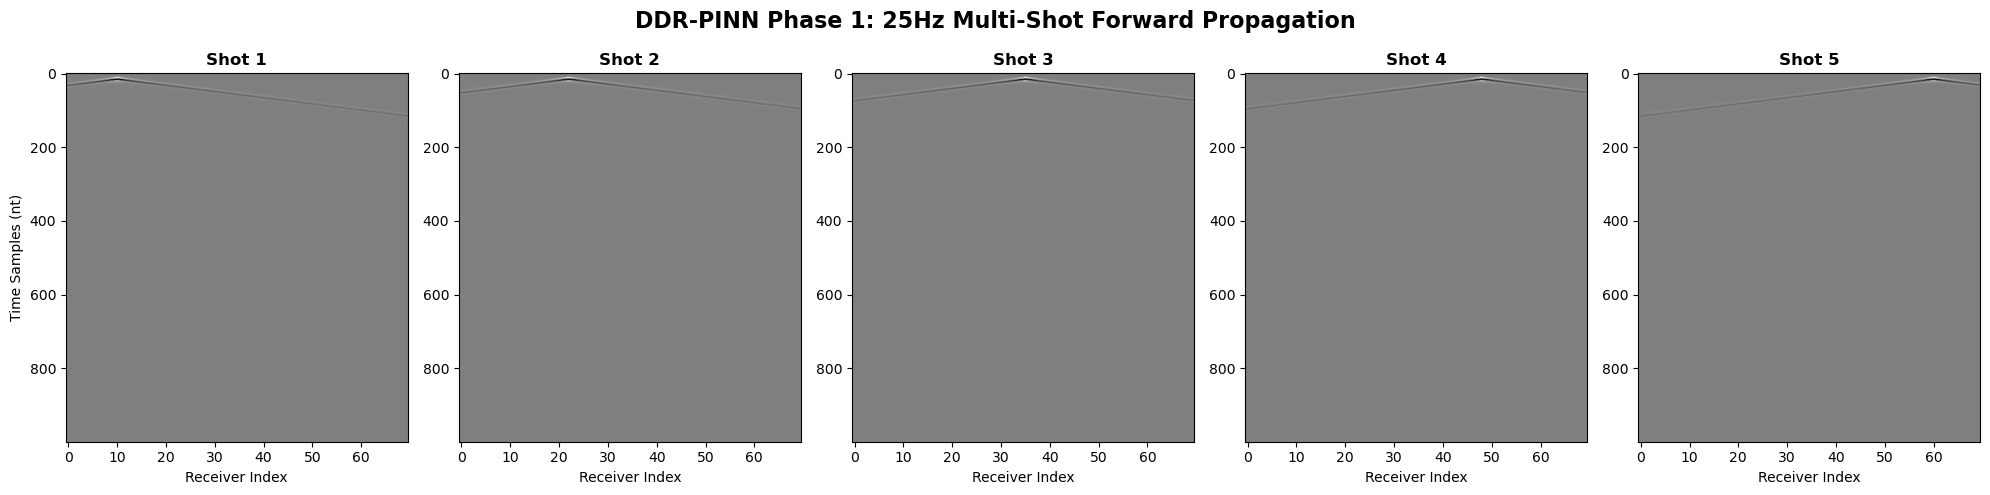

In [3]:
# ==========================================
# CELL 1: DEEPWAVE & AUTOGRAD STRESS TEST
# ==========================================

import torch
import deepwave
import matplotlib.pyplot as plt

# 1. Strict Device Allocation
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type != 'cuda':
    print("WARNING: Executing on CPU. HPC tensor parallelization will be severely bottlenecked.")
else:
    print(f"HPC Node Active: {torch.cuda.get_device_name(0)}\n")

# 2. High-Resolution Baseline Parameters
nx, ny = 70, 70
dx = 10.0
nt = 1000
dt = 0.004
num_shots = 5  

# 3. Velocity Macro-Model (The Neural Network Proxy)
# [Rasht-Behesht 2022 Compliance]: Setting requires_grad=True is the foundational 
# requirement to compute the spatial derivatives for the Physics-Informed Regularization.
v = torch.full((nx, ny), 1500.0, device=device, requires_grad=True)

# 4. Dense Acquisition Geometry Tensors (FIXED: Enforcing integer data types)
source_locations = torch.zeros(num_shots, 1, 2, dtype=torch.long, device=device)
source_locations[:, 0, 0] = 0 # Depth index (Surface = 0)
source_locations[:, 0, 1] = torch.round(torch.linspace(10, nx - 10, num_shots)).long().to(device)

receiver_locations = torch.zeros(num_shots, nx, 2, dtype=torch.long, device=device)
receiver_locations[:, :, 0] = 0 # Depth index (Surface = 0)
receiver_locations[:, :, 1] = torch.arange(nx, dtype=torch.long).repeat(num_shots, 1).to(device)

# 5. Source Wavelet Matrix (25Hz Ricker - STRESS TEST CONFIGURATION)
freq = 25.0
source_amplitudes = (
    deepwave.wavelets.ricker(freq, nt, dt, 1.5 / freq)
    .reshape(1, 1, -1)
    .repeat(num_shots, 1, 1)
    .to(device)
)

print(f"Dispatching full {num_shots}-shot tensor block at {freq}Hz to PyTorch Autograd Engine...")

# 6. Simultaneous Forward Propagation (Zero Python Overhead)
# [DDR-PINN 2026 Architecture]: We explicitly diverge from pure PINNs here. 
# We use Deepwave to compute the transient wavefield u(t, x, z), completely bypassing 
# the spectral bias and massive VRAM bottlenecks.
out = deepwave.scalar(
    v, grid_spacing=dx, dt=dt,
    source_amplitudes=source_amplitudes,
    source_locations=source_locations,
    receiver_locations=receiver_locations
)

print("Executing Adjoint State Backpropagation...")

# 7. Global Gradient Calculation
loss = out[-1].sum()
loss.backward() 

print("\nArchitecture Validated: Full computational graph successfully processed.")
print(f"Gradient Tensor Shape Ready for Optimizer: {v.grad.shape}")

# ==========================================
# 8. VISUALIZATION: THE 5-SHOT SEISMOGRAMS
# ==========================================
# Detach the receiver data from the Autograd graph and push to CPU for plotting
receiver_data = out[-1].detach().cpu().numpy()

fig, axs = plt.subplots(1, num_shots, figsize=(20, 5))
fig.suptitle(f"DDR-PINN Phase 1: {int(freq)}Hz Multi-Shot Forward Propagation", fontsize=16, fontweight='bold')

for i in range(num_shots):
    # Transpose to standard seismic plotting (Time down the Y-axis, Receivers across X-axis)
    # Scaling amplitudes slightly to make the high-frequency arrivals visually distinct
    vmax = np.max(np.abs(receiver_data[i])) if 'np' in globals() else 1.0 # Safe fallback
    import numpy as np # Ensure numpy is imported for scaling
    vmax = np.max(np.abs(receiver_data[i])) * 0.5 
    
    axs[i].imshow(receiver_data[i].T, cmap='gray', aspect='auto', vmin=-vmax, vmax=vmax)
    axs[i].set_title(f"Shot {i+1}", fontweight='bold')
    axs[i].set_xlabel("Receiver Index")
    if i == 0:
        axs[i].set_ylabel("Time Samples (nt)")

# 1. First, lock the layout formatting
plt.tight_layout()

# 2. SECOND, save the high-resolution image to the hard drive
# We use fig.savefig to explicitly target the figure object we created
fig.savefig('ddr_pinn_phase1_25Hz.png', dpi=300, bbox_inches='tight')

# 3. FINALLY, render it to the Jupyter screen (which clears the backend memory)
plt.show()